# Titanic：生存者と非生存者の比較
**run_id:** `v020-exp-01` / **言語:** 日本語

Kaggle参照先：https://www.kaggle.com/competitions/titanic 。AI Data Scientist Skill と Jupyter MCP による記述・関連分析。予測モデルの競技スコアや因果効果は目的としない。

実行とAPI取得はすべてJupyter MCP。構成・Markdown・根拠manifestの編集は `project_manager.enqueue_write`、コードセルの実行結果保存はJupyter MCPが担当する。認証トークンは表示・保存しない。`mcp_gateway.run_and_record` はこの対話で注入可能なPython側MCP transportがないため使用しない（二重実行や偽クライアントを作らず、接続済みMCPのexecute_cellを使用）。外部CSVミラーを使用しない。

In [1]:
import os, json, hashlib, io, contextlib, math
from pathlib import Path
from datetime import datetime, timezone
from dataclasses import asdict
from contextlib import contextmanager
import numpy as np
import pandas as pd
import nbformat
from IPython.display import display
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from ai_data_scientist import project_manager as pm, lifecycle, language_router
from ai_data_scientist import ingestion, cleaning, eda, stats_analysis, visualization
from ai_data_scientist import data_definition, analysis_assumptions, data_quality, sensitivity, notebook_audit

PROJECT = 'kaggle-v020-kaggle-exp-01-titanic'
RUN_ID = 'v020-exp-01'
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = '/home/nahisaho/GitHub/jupytermind/benchmark/projects'
handle = pm.resolve_project(PROJECT, projects_root=os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'])
lifecycle.register_run(RUN_ID, handle.notebook_path)
phase_events = []

def event(name):
    phase_events.append({'phase': name, 'at_utc': datetime.now(timezone.utc).isoformat()})

@contextmanager
def execution_phase(name):
    if lifecycle.is_cancel_requested(RUN_ID):
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('協調的中止が要求されました。')
    lifecycle.mark_execution_start(RUN_ID)
    event('execution_start:' + name)
    try:
        yield
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        event('failed:' + name)
        raise
    finally:
        lifecycle.mark_execution_end(RUN_ID)
        event('execution_end:' + name)

@contextmanager
def write_phase(name):
    lifecycle.mark_write_start(RUN_ID)
    event('write_start:' + name)
    try:
        yield
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        raise
    finally:
        lifecycle.mark_write_end(RUN_ID)
        event('write_end:' + name)

def chart(table, x, y, title, xlabel, ylabel):
    png = visualization.render_chart(table, kind='bar', x=x, y=y, title=title, xlabel=xlabel, ylabel=ylabel)
    output = visualization.build_image_output(png)
    with write_phase('chart:' + title):
        display(output.data, raw=True, metadata=output.metadata)

print('言語:', language_router.detect_language('Titanicの生存者と非生存者の違いを調べてください'))
print('Notebook:', handle.notebook_path)
print('lifecycle:', asdict(lifecycle.get_run_status(RUN_ID)))

言語: ja
Notebook: /home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-01-titanic/notebooks/kaggle-v020-kaggle-exp-01-titanic.ipynb
lifecycle: {'run_id': 'v020-exp-01', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-01-titanic/notebooks/kaggle-v020-kaggle-exp-01-titanic.ipynb', 'reason': None}


## 分析計画（データ比較前に固定）
1. APIで公開データを検索し、原形の学習用CSVを含む候補を選ぶ。構造・生存ラベルを検査し、slug・ファイル・取得日時・SHA-256を保存する。テストデータ・gender_submissionは真の生存ラベルとして使わない。
2. データ定義と分析前提をmanifestに記録する。範囲、カテゴリ、必須列、ID一意性、重複・欠損を検査する。年齢不明を捨てず、群別人数とともに示す。
3. 性別、客室等級、年齢層、運賃四分位、同行家族、乗船港、年齢欠損、客室情報有無を比較する。生存率とWilson 95%区間、人数・生存数を表で示す。年齢・運賃は中央値/IQR・平均・Mann–Whitneyの効果量を併記する。率を主たる比較尺度にし、オッズ比は率差と同一視しない。
4. 可視化は日本語の率棒グラフを採用する。棒は点推定のみで、区間は対応表に掲載。年齢欠損を独立カテゴリとして可視化し、ID・氏名・チケット番号を数値尺度として扱わない。
5. 探索的検定は10比較にHolm補正をする。信頼区間はモデル上の不確実性を示し、無作為抽出や乗客間独立が保証されるわけではない。
6. 初回結果を読み、結論を変えうる未解決点だけを自然言語で追加依頼し、最大3反復。交絡、年齢欠損、同行者の依存性などを優先する。反復を探索的と明記し、因果主張はしない。
7. 新しいカーネルで全コードセルを上から実行し、visual_audit=Trueのnotebook_audit、画像メタデータ、根拠の解決、lifecycle completedを確認する。失敗時は成功として扱わない。

In [2]:
with execution_phase('Kaggle公開データ検索・取得・検証'):
    from kaggle.api.kaggle_api_extended import KaggleApi
    DATASET_SLUG = 'rahulsah06/titanic'
    DATA_FILE = 'train.csv'
    EXPECTED_SHA256 = '7d118fef8b6ccf7f81111877bc388536f7b1e498a655e3d649d19aaa010e9f6f'
    data_dir = pm.ensure_data_dir(handle)
    csv_path = data_dir / DATA_FILE
    provenance_path = data_dir / 'retrieval-manifest.json'
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api = KaggleApi()
            api.authenticate()
            candidates = []
            for page in range(1, 4):
                found = api.dataset_list(search='titanic', file_type='csv', page=page) or []
                candidates.extend({'ref': d.ref, 'title': d.title} for d in found)
                if any(d['ref'] == DATASET_SLUG for d in candidates):
                    break
            if not any(d['ref'] == DATASET_SLUG for d in candidates):
                raise RuntimeError('対応する公開データがAPI検索で見つかりません。')
            file_inventory = {}
            for slug in ['heptapod/titanic', 'yasserh/titanic-dataset', DATASET_SLUG]:
                listing = api.dataset_list_files(slug)
                file_inventory[slug] = [f.name for f in listing.files]
            if DATA_FILE not in file_inventory[DATASET_SLUG]:
                raise RuntimeError('候補データに必要な学習CSVがありません。')
            if not csv_path.exists():
                api.dataset_download_file(DATASET_SLUG, DATA_FILE, path=str(data_dir), quiet=True)
                if not csv_path.exists():
                    import zipfile
                    with zipfile.ZipFile(data_dir / (DATA_FILE + '.zip')) as archive:
                        csv_path.write_bytes(archive.read(DATA_FILE))
                retrieval_manifest = {
                    'run_id': RUN_ID,
                    'competition_reference': 'https://www.kaggle.com/competitions/titanic',
                    'owner_dataset_slug': DATASET_SLUG,
                    'filename': DATA_FILE,
                    'retrieved_at_utc': datetime.now(timezone.utc).isoformat(),
                    'sha256': hashlib.sha256(csv_path.read_bytes()).hexdigest(),
                    'source_kind': 'Kaggle公開データ（競技データの再配布候補、公式とのバイト一致は未確認）'
                }
                with write_phase('retrieval_manifest'):
                    provenance_path.write_text(json.dumps(retrieval_manifest, ensure_ascii=False, indent=2), encoding='utf-8')
            else:
                if not provenance_path.exists():
                    raise RuntimeError('キャッシュに取得manifestがありません。由来不明のデータは使用しません。')
                retrieval_manifest = json.loads(provenance_path.read_text(encoding='utf-8'))
    except Exception as exc:
        print('Kaggle API/由来検証の失敗種別:', type(exc).__name__)
        raise RuntimeError('Kaggle API取得・検証を完了できません。外部ソースにフォールバックせず停止します。認証情報保護のため例外本文は表示しません。') from None
    actual_sha = hashlib.sha256(csv_path.read_bytes()).hexdigest()
    assert actual_sha == retrieval_manifest['sha256'] == EXPECTED_SHA256, '保存済みCSVのSHA-256が変更されています。'
    assert retrieval_manifest['owner_dataset_slug'] == DATASET_SLUG and retrieval_manifest['filename'] == DATA_FILE
    loaded = ingestion.ingest(ingestion.SourceSpec(kind='csv', location=str(csv_path)))
    df_raw = loaded.dataframe
    required = {'PassengerId','Survived','Pclass','Name','Sex','Age','SibSp','Parch','Ticket','Fare','Cabin','Embarked'}
    assert set(df_raw.columns) == required and len(df_raw) == 891 and not loaded.truncated
    assert df_raw['Survived'].value_counts().to_dict() == {0:549, 1:342}
    print('検索候補:', json.dumps(candidates, ensure_ascii=False))
    print('APIファイル一覧:', json.dumps(file_inventory, ensure_ascii=False))
    print('選定理由: 原形のtrain.csv/test.csvを分離して持つ公開データを優先。結合済み・cleanedデータと推測ラベルを避ける。')
    print('取得manifest:', json.dumps(retrieval_manifest, ensure_ascii=False, indent=2))
    print('API再確認日時UTC:', datetime.now(timezone.utc).isoformat())
    print('再実行では検証済みキャッシュを使用。取得日は初回のまま維持し、SHAを毎回検査。')
    print('標準学習データと形状・ラベル集計が一致。ただし公式競技CSVとのバイト一致を保証しない。')

検索候補: [{"ref": "heptapod/titanic", "title": "Titanic"}, {"ref": "brendan45774/test-file", "title": "Titanic dataset"}, {"ref": "yasserh/titanic-dataset", "title": "Titanic Dataset"}, {"ref": "azeembootwala/titanic", "title": "Titanic"}, {"ref": "rahulsah06/titanic", "title": "Titanic "}, {"ref": "sakshisatre/titanic-dataset", "title": "Titanic Dataset"}, {"ref": "shubhamgupta012/titanic-dataset", "title": "Titanic Dataset"}, {"ref": "lovishbansal123/titanic-dataset", "title": "Titanic Dataset"}, {"ref": "fossouodonald/titaniccsv", "title": "Titanic csv"}, {"ref": "zain280/titanic-data-set", "title": "Titanic Data set"}, {"ref": "prkukunoor/TitanicDataset", "title": "Titanic"}, {"ref": "jamesleslie/titanic-cleaned-data", "title": "Titanic: cleaned data"}, {"ref": "ashishkumarjayswal/titanic-datasets", "title": "Titanic Survival Datasets"}, {"ref": "smirkxd/titanic-dataset", "title": "Titanic Dataset"}, {"ref": "kittisaks/testtitanic", "title": "test titanic"}, {"ref": "mahmoudshogaa/tit

## データ定義・前提・意味的異常検査
再配布データの説明にデータ辞書がないため、単位・意味の確認状態を誇張しない。観測したカテゴリ・値域の一致は「意味の検証」ではない。客室等級、年齢、運賃、同行者の意味は標準的なTitanic列名からの推定として扱う。特に運賃は1人当たり価格と断言できず、通貨単位も未検証。CabinKnownは居住区画の優劣ではなく記録の有無にすぎない。

独立した参照データは与えられていない。同じ競技データの別再配布は独立標本ではないので、validate_anomalies・compare_datasetsによる外部妥当性検証は適用しない。極端に高い運賃・幼児の小数年齢は即エラーとはせず、意味的範囲チェックと感度分析を使う。

In [3]:
with execution_phase('manifest・品質検査・前処理'):
    F = data_definition.FieldValue
    definitions = {
        'PassengerId': ('レコードの乗客識別子', '識別子'),
        'Survived': ('生存ラベル（0=非生存、1=生存）', '二値'),
        'Pclass': ('客室等級（1/2/3）', 'カテゴリ'),
        'Sex': ('データに記録された性別', 'カテゴリ'),
        'Age': ('乗客年齢、幼児は小数を含む', '年と推定'),
        'SibSp': ('同乗きょうだい・配偶者数と推定', '人数'),
        'Parch': ('同乗親・子数と推定', '人数'),
        'Fare': ('記録された運賃、個人料金か共同チケット料金か未確定', None),
        'Embarked': ('乗船港コード（C/Q/S）', 'カテゴリ'),
        'Cabin': ('客室情報。欠損は不明であり無客室とは解釈しない', '文字列'),
        'Ticket': ('チケット識別子。同一番号の乗客は独立でない可能性', '識別子'),
        'Name': ('氏名。個人の表示・ランキングには使用しない', '文字列'),
        'FamilySize': ('SibSp + Parch + 1。本データ上の同行家族人数指標', '人数')
    }
    definition_manifest = data_definition.build_manifest(
        source={'value': DATASET_SLUG, 'status': 'verified', 'sha256': actual_sha},
        dataset_scope={'value': 'train.csvの891レコード。全乗客や無作為標本ではない', 'status': 'verified'},
        variables={name: {'meaning': F(meaning, 'inferred', '列名・値域と一般的なTitanic定義。再配布辞書は未確認'),
                          'unit': F(unit, 'unknown' if unit is None else 'inferred')}
                   for name, (meaning, unit) in definitions.items()},
        transformations=('重複検査（除去0件）', 'FamilySize=SibSp+Parch+1', '年齢不明を別群', 'Fareの標本内四分位', '客室記録有無')
    )
    print('データ定義manifest:', json.dumps(asdict(definition_manifest), ensure_ascii=False, default=str))
    print('未解決定義:', definition_manifest.unresolved_fields())
    assumptions_manifest = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'target':'取得した学習レコードにおける生存との関連'},
        causal_scope='associational',
        sampling={'design':'競技の学習標本、抽出機構は不明','n':891,'seed':None},
        assumptions=(
            analysis_assumptions.Assumption('label-meaning', 'Survivedの意味・符号化が標準Titanicと同じ', 'assumed', conclusion_critical=True, impact_if_false='生存に関する全解釈が変わる'),
            analysis_assumptions.Assumption('source-correspondence', '公開再配布が競技train.csvに対応する', 'assumed', conclusion_critical=True, impact_if_false='競技データについての一般化を制限'),
            analysis_assumptions.Assumption('descriptive-only', '条件付き関連を原因と解釈しない', 'verified'),
            analysis_assumptions.Assumption('age-missing', '年齢欠損はランダムとは仮定せず別群・感度分析で検討', 'assumed', impact_if_false='子供・成人比較の一般化を制限'),
            analysis_assumptions.Assumption('independent-ci', '初回のWilson区間・検定は乗客独立の近似', 'assumed', impact_if_false='区間・p値が過度に精密になる可能性')
        )
    )
    print('分析前提manifest:', json.dumps(asdict(assumptions_manifest), ensure_ascii=False))
    print('前提検査finding:', [asdict(f) for f in analysis_assumptions.check_manifest(assumptions_manifest)])
    schema = {
        'PassengerId': {'not_null':True, 'unique':True, 'min':1},
        'Survived': {'not_null':True, 'allowed':[0,1]},
        'Pclass': {'not_null':True, 'allowed':[1,2,3]},
        'Sex': {'not_null':True, 'allowed':['male','female']},
        'Age': {'min':0, 'max':100},
        'Fare': {'min':0, 'not_null':True},
        'SibSp': {'min':0, 'max':20, 'not_null':True},
        'Parch': {'min':0, 'max':20, 'not_null':True},
        'Embarked': {'allowed':['C','Q','S']}
    }
    semantic_anomalies = data_quality.detect_anomalies(df_raw, schema=schema)
    print('意味的異常:', [asdict(a) for a in semantic_anomalies])
    assert not semantic_anomalies, '意味的異常が見つかったため分析前に確認が必要です。'
    assert all((df_raw[c].dropna() % 1 == 0).all() for c in ['PassengerId','Pclass','SibSp','Parch','Survived'])
    cleaned = cleaning.clean_dataset(df_raw, operation='drop_duplicates')
    print('クリーニング:', {k:v for k,v in vars(cleaned).items() if not isinstance(v,pd.DataFrame)})
    df = next(v for v in vars(cleaned).values() if isinstance(v,pd.DataFrame)).copy()
    assert len(df) == len(df_raw), '予期しない重複がありました。'
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['FamilyGroup'] = pd.cut(df['FamilySize'], bins=[0,1,4,20], labels=['1人','2–4人','5人以上']).astype(str)
    df['AgeGroup'] = pd.cut(df['Age'], bins=[-0.01,12,18,35,60,100], right=False,
                            labels=['0–11歳','12–17歳','18–34歳','35–59歳','60歳以上']).astype(object).fillna('年齢不明')
    df['AgeMissing'] = df['Age'].isna().map({True:'年齢不明',False:'年齢あり'})
    df['CabinKnown'] = df['Cabin'].notna().map({True:'客室記録あり',False:'客室記録なし'})
    df['Embarked'] = df['Embarked'].fillna('不明')
    df['FareQuartile'] = pd.qcut(df['Fare'], 4, labels=['Q1低','Q2','Q3','Q4高'])
    df['Female'] = (df['Sex']=='female').astype(int)
    overview = eda.explore(df_raw)
    print('EDA報告項目:', list(vars(overview)))
    print('列型・欠損:', pd.DataFrame({'dtype':df_raw.dtypes.astype(str),'missing_n':df_raw.isna().sum(),'missing_pct':df_raw.isna().mean()*100}).to_string())
    print('数値要約:',df_raw[['Age','Fare','SibSp','Parch']].describe().to_string())
    print('元データのレコード削除:0、年齢/客室欠損の補完:0、港コード不明の分類:2。')
    print('運賃ゼロ件数:',int(df['Fare'].eq(0).sum()), '運賃最大:',df['Fare'].max(), '同一Ticket複数人のレコード数:',int(df['Ticket'].duplicated(keep=False).sum()))

データ定義manifest: {"source": {"value": "rahulsah06/titanic", "status": "verified", "sha256": "7d118fef8b6ccf7f81111877bc388536f7b1e498a655e3d649d19aaa010e9f6f"}, "dataset_scope": {"value": "train.csvの891レコード。全乗客や無作為標本ではない", "status": "verified"}, "variables": {"PassengerId": {"meaning": {"value": "レコードの乗客識別子", "status": "inferred", "source": "列名・値域と一般的なTitanic定義。再配布辞書は未確認"}, "unit": {"value": "識別子", "status": "inferred", "source": null}}, "Survived": {"meaning": {"value": "生存ラベル（0=非生存、1=生存）", "status": "inferred", "source": "列名・値域と一般的なTitanic定義。再配布辞書は未確認"}, "unit": {"value": "二値", "status": "inferred", "source": null}}, "Pclass": {"meaning": {"value": "客室等級（1/2/3）", "status": "inferred", "source": "列名・値域と一般的なTitanic定義。再配布辞書は未確認"}, "unit": {"value": "カテゴリ", "status": "inferred", "source": null}}, "Sex": {"meaning": {"value": "データに記録された性別", "status": "inferred", "source": "列名・値域と一般的なTitanic定義。再配布辞書は未確認"}, "unit": {"value": "カテゴリ", "status": "inferred", "source": null}}, "Age": {"meaning": {

## 初回比較：率、分布、効果量
率の分母は各群の全レコード。連続変数の要約のみ当該変数の観測値を使う。Wilson区間は95%の点別区間で、群間差の区間や多重比較の同時区間ではない。Mann–Whitneyは平均差の検定ではなく順位分布の比較である。

In [12]:
with execution_phase('初回群間比較'):
    def wilson(k, n):
        z = stats.norm.ppf(0.975)
        p = k/n
        den = 1 + z*z/n
        center = (p + z*z/(2*n))/den
        half = z*math.sqrt(p*(1-p)/n + z*z/(4*n*n))/den
        return center-half, center+half

    def rate_table(data, columns):
        tab = data.groupby(columns, observed=True, dropna=False)['Survived'].agg(n='size',survivors='sum').reset_index()
        tab['rate_pct'] = 100*tab['survivors']/tab['n']
        cis = [wilson(int(k),int(n)) for k,n in zip(tab['survivors'],tab['n'])]
        tab['ci_low_pct'] = [100*x[0] for x in cis]
        tab['ci_high_pct'] = [100*x[1] for x in cis]
        return tab

    total = rate_table(df.assign(Group='全体'), ['Group'])
    print('全体:', total.to_string(index=False,float_format=lambda x:f'{x:.6f}'))
    tables = {}
    tests = []
    for col in ['Sex','Pclass','AgeGroup','FareQuartile','FamilyGroup','Embarked','AgeMissing','CabinKnown']:
        tables[col] = rate_table(df,[col])
        print('\n群別:', col)
        print(tables[col].to_string(index=False, float_format=lambda x:f'{x:.6f}'))
        test_data = df.loc[df['Embarked'] != '不明'] if col == 'Embarked' else df
        chi, p, dof, expected = stats.chi2_contingency(pd.crosstab(test_data[col],test_data['Survived']),correction=False)
        tests.append({'comparison':col,'test':'chi-square','p_raw':p,'effect':math.sqrt(chi/len(test_data)),'effect_name':'Cramers V','expected_min':expected.min()})
    continuous_rows=[]
    for col in ['Age','Fare']:
        a = df.loc[df['Survived']==1,col].dropna()
        b = df.loc[df['Survived']==0,col].dropna()
        for label, values in [('生存',a),('非生存',b)]:
            continuous_rows.append({'variable':col,'group':label,'n':len(values),'mean':values.mean(),'median':values.median(),'q25':values.quantile(.25),'q75':values.quantile(.75)})
        u,p=stats.mannwhitneyu(a,b,alternative='two-sided')
        tests.append({'comparison':col,'test':'Mann-Whitney','p_raw':p,'effect':2*u/(len(a)*len(b))-1,'effect_name':'rank-biserial survival minus non-survival','expected_min':np.nan})
    continuous = pd.DataFrame(continuous_rows)
    test_table = pd.DataFrame(tests)
    test_table['p_holm'] = multipletests(test_table['p_raw'],method='holm')[1]
    print('\n連続変数要約:',continuous.to_string(index=False,float_format=lambda x:f'{x:.6f}'))
    print('\n探索的検定（Holm補正10比較）:',test_table.to_string(index=False,float_format=lambda x:f'{x:.8g}'))
    marginal_correlation = stats_analysis.correlation(df,'Female','Survived',language='ja')
    print('点双列相関:',marginal_correlation)
    print('女性と男性の粗生存率差pp:',100*(df.loc[df.Female==1,'Survived'].mean()-df.loc[df.Female==0,'Survived'].mean()))
    print('1等と3等の粗生存率差pp:',100*(df.loc[df.Pclass==1,'Survived'].mean()-df.loc[df.Pclass==3,'Survived'].mean()))
    display({'text/plain': tables['Sex'].to_string(index=False, float_format=lambda x:f'{x:.6f}') + '\n' + tables['Pclass'].to_string(index=False, float_format=lambda x:f'{x:.6f}') + '\n' + tables['FamilyGroup'].to_string(index=False, float_format=lambda x:f'{x:.6f}')}, raw=True)

全体: Group   n  survivors  rate_pct  ci_low_pct  ci_high_pct
   全体 891        342 38.383838   35.246943    41.620468

群別: Sex
   Sex   n  survivors  rate_pct  ci_low_pct  ci_high_pct
female 314        233 74.203822   69.092531    78.730053
  male 577        109 18.890815   15.906601    22.286516

群別: Pclass
 Pclass   n  survivors  rate_pct  ci_low_pct  ci_high_pct
      1 216        136 62.962963   56.349005    69.123897
      2 184         87 47.282609   40.198263    54.478098
      3 491        119 24.236253   20.655428    28.217086

群別: AgeGroup
AgeGroup   n  survivors  rate_pct  ci_low_pct  ci_high_pct
   0–11歳  68         39 57.352941   45.516782    68.402757
  12–17歳  45         22 48.888889   34.957024    62.995535
  18–34歳 366        135 36.885246   32.102219    41.940713
  35–59歳 209         87 41.626794   35.153827    48.402009
   60歳以上  26          7 26.923077   13.704448    46.083040
    年齢不明 177         52 29.378531   23.163447    36.469703

群別: FareQuartile
FareQuartile   

   Sex   n  survivors  rate_pct  ci_low_pct  ci_high_pct
female 314        233 74.203822   69.092531    78.730053
  male 577        109 18.890815   15.906601    22.286516
 Pclass   n  survivors  rate_pct  ci_low_pct  ci_high_pct
      1 216        136 62.962963   56.349005    69.123897
      2 184         87 47.282609   40.198263    54.478098
      3 491        119 24.236253   20.655428    28.217086
FamilyGroup   n  survivors  rate_pct  ci_low_pct  ci_high_pct
         1人 537        163 30.353818   26.615877    34.370842
       2–4人 292        169 57.876712   52.147092    63.401777
       5人以上  62         10 16.129032    9.004069    27.206336

### 初回図表の読み方
性別・等級・年齢・運賃四分位・同行家族の率を表示する。すべて割合で比較し、人数の違いは上の表で確認する。性別と生存の相関は二値同士の周辺関連であり、等級や年齢を調整した効果ではない。運賃の四分位境界はこの標本内の相対的分類で、通貨や1人当たり価格に関する主張には使わない。

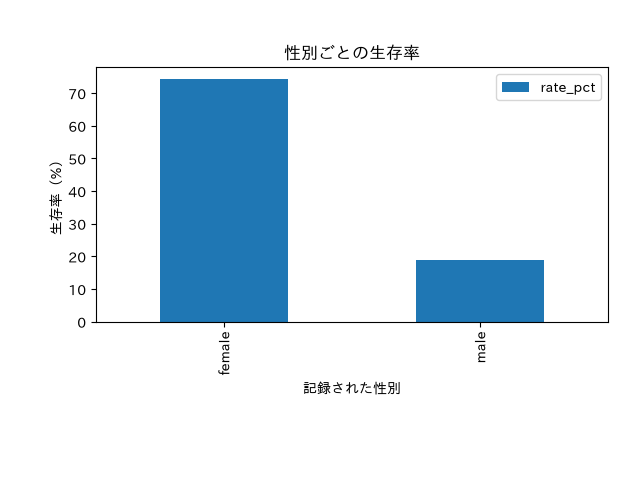

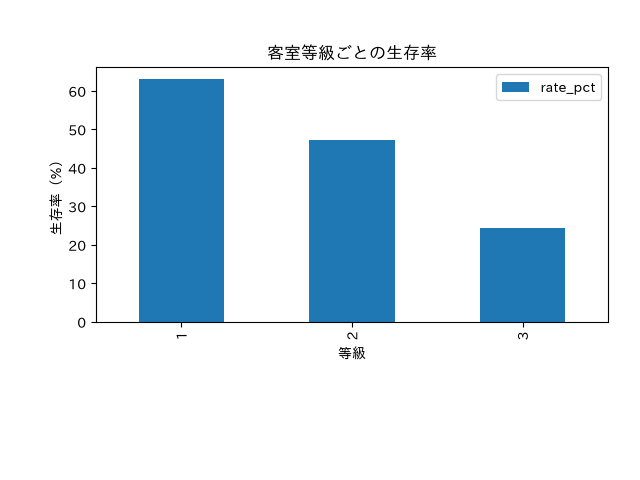

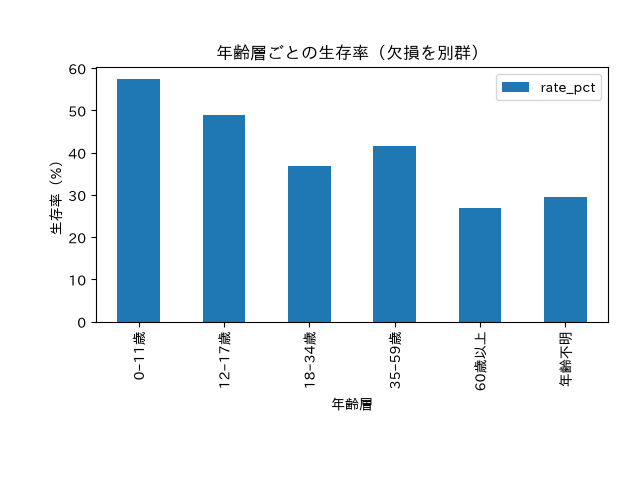

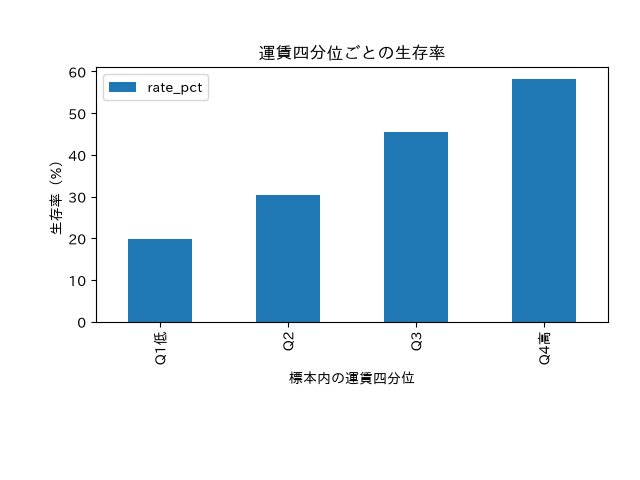

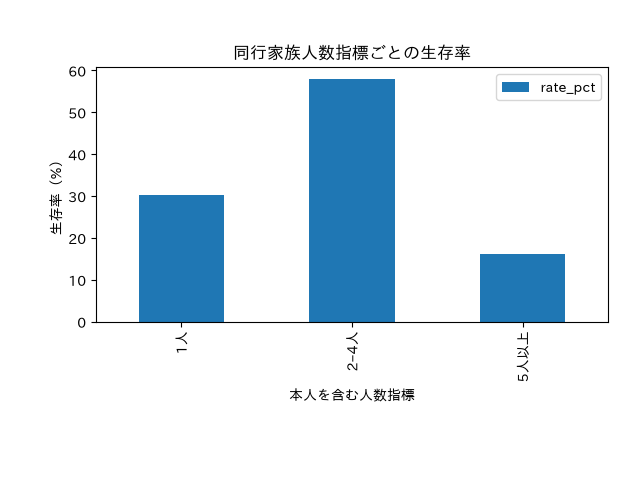

In [14]:
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.subplot.bottom':0.33,'figure.subplot.top':0.86,'figure.subplot.left':0.15,'figure.subplot.right':0.95})
with execution_phase('初回図表'):
    chart(tables['Sex'], 'Sex', 'rate_pct', '性別ごとの生存率', '記録された性別', '生存率（%）')
    chart(tables['Pclass'].assign(Pclass=tables['Pclass']['Pclass'].astype(str)), 'Pclass', 'rate_pct', '客室等級ごとの生存率', '等級', '生存率（%）')
    age_plot = tables['AgeGroup'].set_index('AgeGroup').reindex(['0–11歳','12–17歳','18–34歳','35–59歳','60歳以上','年齢不明']).reset_index()
    chart(age_plot, 'AgeGroup', 'rate_pct', '年齢層ごとの生存率（欠損を別群）', '年齢層', '生存率（%）')
    chart(tables['FareQuartile'], 'FareQuartile', 'rate_pct', '運賃四分位ごとの生存率', '標本内の運賃四分位', '生存率（%）')
    chart(tables['FamilyGroup'], 'FamilyGroup', 'rate_pct', '同行家族人数指標ごとの生存率', '本人を含む人数指標', '生存率（%）')

初回結果：女性74.203822%（233/314）、男性18.890815%（109/577）。1等62.962963%、2等47.282609%、3等24.236253%。性別・等級に大きな関連がある。ただし粗比較で、原因とは言えない。

```evidence
{"execution_count":12,"cited_value":"74.203822","claim_type":"descriptive"}
```

初回結果：同行家族2–4人は57.876712%、1人30.353818%、5人以上16.129032%。年齢中央値は両群とも28歳で、単純な「生存者は若い」は不適切。運賃中央値は生存26、非生存10.5だが、等級や共同チケットを未調整。

```evidence
{"execution_count":12,"cited_value":"57.876712","claim_type":"descriptive"}
```

## 反復依頼履歴
### 反復1：性別と等級の交絡
**選定理由:** 大きな粗生存率差が、他方の群構成によるだけか確認する。

**追加依頼文（原文）:**
> 性別と客室等級を組み合わせて、生存率と人数・95%区間を比較してください。女性と男性の差が各等級で同じ方向か、1等と3等の差が男女それぞれで同じ方向か確認し、共通の等級・性別構成に標準化した率差と比較してください。未調整の差を原因と解釈しないでください。

性別×等級:  Pclass    Sex   n  survivors  rate_pct  ci_low_pct  ci_high_pct
      1 female  94         91 96.808511   91.032685    98.908737
      1   male 122         45 36.885246   28.846080    45.725098
      2 female  76         70 92.105263   83.827257    96.331599
      2   male 108         17 15.740741   10.066203    23.768709
      3 female 144         72 50.000000   41.940280    58.059720
      3   male 347         47 13.544669   10.340909    17.546747
等級内の女性−男性の率差pp: Sex       female      male  female_minus_male_pp
Pclass                                          
1      96.808511 36.885246             59.923265
2      92.105263 15.740741             76.364522
3      50.000000 13.544669             36.455331
共通等級構成の性別率: {'female': 70.04265625019639, 'male': 19.656500210670544}
共通性別構成の等級率: {1: 58.00298454059645, 2: 42.652592636348324, 3: 26.39200199238624}
性別内の1等−3等の率差pp: {'female': 46.808510638297875, 'male': 23.34057731374309}
標準化は標本の共通構成への記述的比較。年齢・他の交絡は未調整。


標準化女性−男性の率差pp: 50.386156
標準化1等−3等の率差pp: 31.610983

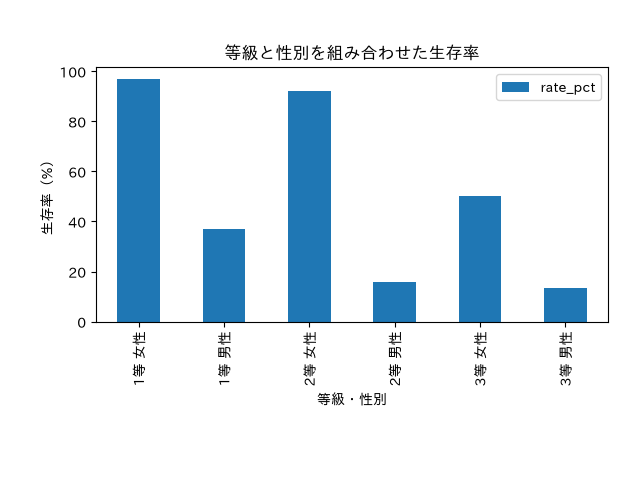

In [15]:
with execution_phase('反復1：層別・構成標準化'):
    sex_class = rate_table(df, ['Pclass','Sex'])
    print('性別×等級:', sex_class.to_string(index=False, float_format=lambda x:f'{x:.6f}'))
    sex_class_rates = sex_class.pivot(index='Pclass',columns='Sex',values='rate_pct')
    sex_class_rates['female_minus_male_pp'] = sex_class_rates['female']-sex_class_rates['male']
    print('等級内の女性−男性の率差pp:',sex_class_rates.to_string(float_format=lambda x:f'{x:.6f}'))
    class_weights = df['Pclass'].value_counts(normalize=True).sort_index()
    standardized_sex = sex_class_rates[['female','male']].mul(class_weights,axis=0).sum()
    standardized_sex_gap = float(standardized_sex['female']-standardized_sex['male'])
    sex_weights = df['Sex'].value_counts(normalize=True)
    standardized_class = sex_class.pivot(index='Pclass',columns='Sex',values='rate_pct').mul(sex_weights,axis=1).sum(axis=1)
    print('共通等級構成の性別率:',standardized_sex.to_dict())
    print('共通性別構成の等級率:',standardized_class.to_dict())
    display({'text/plain':f'標準化女性−男性の率差pp: {standardized_sex_gap:.6f}\n標準化1等−3等の率差pp: {standardized_class.loc[1]-standardized_class.loc[3]:.6f}'},raw=True)
    print('性別内の1等−3等の率差pp:',(sex_class_rates.loc[1,['female','male']]-sex_class_rates.loc[3,['female','male']]).to_dict())
    joint_plot=sex_class.assign(Group=sex_class['Pclass'].astype(str)+'等 '+sex_class['Sex'].map({'female':'女性','male':'男性'}))
    chart(joint_plot,'Group','rate_pct','等級と性別を組み合わせた生存率','等級・性別','生存率（%）')
    print('標準化は標本の共通構成への記述的比較。年齢・他の交絡は未調整。')

反復1の結果：共通等級構成で標準化した女性−男性の率差は50.386156ポイント、共通性別構成で標準化した1等−3等は31.610983ポイント。性別差は各等級、等級差は男女双方で同方向。群構成だけでは粗差を説明できないが、差の大きさは等級・性別で異なる。残る限界：年齢その他の未調整要因と非無作為標本。

```evidence
{"execution_count":15,"cited_value":"50.386156","claim_type":"associational"}
```

### 反復2：年齢欠損と子供の定義
**選定理由:** 性別と等級の関連は層別でも残った。一方で年齢中央値は同じなのに幼い群の率が高く、年齢欠損も多い。子供に関する結論は閾値・欠損処理で変わりうる。

**追加依頼文（原文）:**
> 年齢不明の人と年齢が記録された人で生存率や性別・等級構成が違うか調べてください。子供の境界を12歳未満・16歳未満・18歳未満に変え、年齢完全ケースと性別×等級別中央値補完で、性別・等級・同行家族を調整した子供の関連を比較してください。12歳未満について欠損年齢の極端な割り当てで率差が反転しうるかも示し、感度分析の安定性と限界を説明してください。

統計モデルは二項GLM（ロジットリンク）を関連の要約にのみ使用。中央値補完は検証済みの真の年齢ではなく仕様比較。閾値はすべて「未満」。極端割当は現実的推定ではなく未識別性の幅を示す。

In [17]:
with execution_phase('反復2：年齢感度分析'):
    print('年齢欠損×性別×等級:',rate_table(df,['AgeMissing','Sex','Pclass']).to_string(index=False,float_format=lambda x:f'{x:.6f}'))
    print('欠損群の構成比:',pd.crosstab(df['AgeMissing'],[df['Sex'],df['Pclass']],normalize='index').to_string(float_format=lambda x:f'{x:.6f}'))
    age_records=[]
    def age_analysis(threshold, missing):
        d=df.copy()
        if missing=='complete':
            d=d.loc[d['Age'].notna()].copy()
        elif missing=='group_median':
            d['Age']=d['Age'].fillna(d.groupby(['Sex','Pclass'])['Age'].transform('median'))
        else:
            raise ValueError('未知の欠損仕様')
        assert d['Age'].notna().all()
        d['Child']=(d['Age']<threshold).astype(int)
        model=smf.glm('Survived ~ Female * C(Pclass) + Child + C(FamilyGroup)',data=d,family=sm.families.Binomial()).fit()
        assert model.converged
        ci=model.conf_int().loc['Child']
        odds=math.exp(model.params['Child'])
        rates=d.groupby('Child')['Survived'].mean()
        age_records.append({'threshold':threshold,'missing':missing,'n':len(d),'child_n':int(d.Child.sum()),'child_rate_pct':100*rates.loc[1],'other_rate_pct':100*rates.loc[0],'adjusted_child_OR':odds,'OR_low':math.exp(ci.iloc[0]),'OR_high':math.exp(ci.iloc[1])})
        return odds
    age_plan=sensitivity.SensitivityPlan(parameter_grid={'threshold':[12,16,18],'missing':['complete','group_median']},max_runs=6)
    age_sensitivity=sensitivity.run_sensitivity(age_plan,age_analysis,stability_tolerance=.20)
    age_results=pd.DataFrame(age_records)
    print('年齢感度分析:',age_results.to_string(index=False,float_format=lambda x:f'{x:.6f}'))
    print('sensitivity report:',json.dumps(asdict(age_sensitivity),ensure_ascii=False,default=str))
    known=df.loc[df['Age'].notna()]
    child=known.loc[known['Age']<12,'Survived']
    other=known.loc[known['Age']>=12,'Survived']
    unknown=df.loc[df['Age'].isna(),'Survived']
    us=int(unknown.sum()); ud=len(unknown)-us
    k1=int(child.sum()); n1=len(child); k0=int(other.sum()); n0=len(other)
    lower_gap=100*(k1/(n1+ud)-(k0+us)/(n0+us))
    upper_gap=100*((k1+us)/(n1+us)-k0/(n0+ud))
    display({'text/plain':f'AgeMissing n={len(unknown)}, survivors={us}, non_survivors={ud}\n12歳未満の率差・極端割当下限pp: {lower_gap:.6f}\n12歳未満の率差・極端割当上限pp: {upper_gap:.6f}\nage_sensitivity.stable={age_sensitivity.stable}\nage_sensitivity.max_relative_deviation={age_sensitivity.max_relative_deviation:.6f}\n'+age_results.to_string(index=False,float_format=lambda x:f'{x:.6f}')},raw=True)
    print('子供ORは性別×等級・家族群を調整。区間は独立近似で反復3に依存性検討を残す。')

年齢欠損×性別×等級: AgeMissing    Sex  Pclass   n  survivors   rate_pct  ci_low_pct  ci_high_pct
      年齢あり female       1  85         82  96.470588   90.129952    98.792496
      年齢あり female       2  74         68  91.891892   83.418058    96.231015
      年齢あり female       3 102         47  46.078431   36.723487    55.718039
      年齢あり   male       1 101         40  39.603960   30.615423    49.354333
      年齢あり   male       2  99         15  15.151515    9.402325    23.504111
      年齢あり   male       3 253         38  15.019763   11.142493    19.943400
      年齢不明 female       1   9          9 100.000000   70.085495   100.000000
      年齢不明 female       2   2          2 100.000000   34.238023   100.000000
      年齢不明 female       3  42         25  59.523810   44.494313    72.957139
      年齢不明   male       1  21          5  23.809524   10.628013    45.091174
      年齢不明   male       2   9          2  22.222222    6.322511    54.741103
      年齢不明   male       3  94          9   9.574468    5.119196 

AgeMissing n=177, survivors=52, non_survivors=125
12歳未満の率差・極端割当下限pp: -23.202488
12歳未満の率差・極端割当上限pp: 43.278210
age_sensitivity.stable=False
age_sensitivity.max_relative_deviation=0.552129
 threshold      missing   n  child_n  child_rate_pct  other_rate_pct  adjusted_child_OR   OR_low   OR_high
        12     complete 714       68       57.352941       38.854489          10.520068 4.557606 24.282884
        12 group_median 891       68       57.352941       36.816525          10.055033 4.414380 22.903259
        16     complete 714       83       59.036145       38.193344           9.012767 4.233583 19.187050
        16 group_median 891       83       59.036145       36.262376           8.218192 3.905317 17.294034
        18     complete 714      113       53.982301       38.103161           5.083705 2.793223  9.252416
        18 group_median 891      113       53.982301       36.118252           4.711632 2.619511  8.474665

反復2の結果：年齢不明は177人（うち生存52人）で、3等男性の構成比が高い。検討した6仕様では子供の調整ORはすべて1を上回るが、10.520068から4.711632へ変わり、stable=False、最大相対偏差0.552129（55.2%）。12歳未満の粗率差は欠損年齢の極端割当で−23.202488〜43.278210ポイントとなり反転可能。子供の関連の大きさ・欠損者まで含めた一般化は頑健ではない。残る限界：共通子供ORというモデル制約、補完の不確実性、同行者依存性。ORは生存確率の倍率ではない。

```evidence
{"execution_count":17,"cited_value":"0.552129","claim_type":"associational"}
```

### 反復3：同行者の依存性、家族差・運賃差の調整
**選定理由:** 初回の小家族の差や運賃の差は性別・等級・年齢と重なる。同じチケットを持つ乗客を独立と見なすと区間が過度に狭くなりうる。主要な性別差の頑健性と、運賃を独立した要因と解釈してよいかを確認する価値が残った。

**追加依頼文（原文）:**
> 同一チケットの乗客をまとめたクラスターブートストラップで、等級構成を標準化した性別差の95%区間を確認してください。性別×等級・年齢層・同行家族を含む二項GLMを使い、チケット単位のクラスターロバスト区間を示してください。運賃上位1%の除外、記録運賃と標本内同一チケット人数で割った指標、年齢不明を別群にする方法と完全ケースを比較し、性別差・同行家族差・運賃の関連の解釈がどの程度変わるか説明してください。これらを因果効果とは呼ばないでください。

ブートストラップは1000回・固定seed=20261002。チケット間も独立とは保証できない。運賃/標本内Ticket人数は感度指標であり真の1人当たり運賃ではない。全員が学習標本に含まれない可能性がある。8仕様に限定し、20%相対偏差を性別率差の大きさの安定基準とする。

In [19]:
with execution_phase('反復3：依存性と調整感度分析'):
    ticket_codes, ticket_labels = pd.factorize(df['Ticket'])
    G=len(ticket_labels)
    strata=(df['Pclass'].to_numpy()-1)*2+df['Female'].to_numpy()
    count_matrix=np.zeros((G,6))
    survival_matrix=np.zeros((G,6))
    np.add.at(count_matrix,(ticket_codes,strata),1)
    np.add.at(survival_matrix,(ticket_codes,strata),df['Survived'].to_numpy())
    rng=np.random.default_rng(20261002)
    bootstrap_weights=rng.multinomial(G,np.repeat(1/G,G),size=1000)
    boot_counts=bootstrap_weights@count_matrix
    boot_survivors=bootstrap_weights@survival_matrix
    valid=(boot_counts>0).all(axis=1)
    assert valid.all(), 'ブートストラップに空の性別等級層が生じました。'
    boot_rates=boot_survivors/boot_counts
    boot_gap=100*((boot_rates[:,[1,3,5]]-boot_rates[:,[0,2,4]])@class_weights.to_numpy())
    boot_ci=np.quantile(boot_gap,[.025,.975])
    print('チケット数:',G,'複数乗客Ticketのレコード数:',int(df.Ticket.duplicated(keep=False).sum()),'最大標本内チケット人数:',int(df.Ticket.value_counts().max()))
    display({'text/plain':f'等級標準化性別差pp: {standardized_sex_gap:.6f}\nTicketクラスターブートストラップ95%下限pp: {boot_ci[0]:.6f}\nTicketクラスターブートストラップ95%上限pp: {boot_ci[1]:.6f}\nbootstrap_n=1000, seed=20261002, valid={int(valid.sum())}'},raw=True)
    model_records=[]
    fitted_models={}
    base_formula='Survived ~ Female * C(Pclass) + C(AgeGroup) + C(FamilyGroup) + LogFare'
    def adjusted_analysis(subset, fare_measure, age_mode):
        d=df.copy()
        ticket_n=d.groupby('Ticket')['PassengerId'].transform('size')
        d['FareProxy']=d['Fare'] if fare_measure=='recorded' else d['Fare']/ticket_n
        if subset=='trim99':
            d=d.loc[d['Fare']<=df['Fare'].quantile(.99)].copy()
        elif subset!='all':
            raise ValueError('未知のsubset')
        if age_mode=='complete':
            d=d.loc[d['Age'].notna()].copy()
        elif age_mode!='unknown_group':
            raise ValueError('未知の年齢仕様')
        d['LogFare']=np.log1p(d['FareProxy'])
        model=smf.glm(base_formula,data=d,family=sm.families.Binomial()).fit(cov_type='cluster',cov_kwds={'groups':d['Ticket']})
        assert model.converged and np.isfinite(model.params).all()
        gap=100*(model.predict(d.assign(Female=1))-model.predict(d.assign(Female=0))).mean()
        ci=model.conf_int().loc['LogFare']
        model_records.append({'subset':subset,'fare_measure':fare_measure,'age_mode':age_mode,'n':len(d),'clusters':d.Ticket.nunique(),'sex_standardized_gap_pp':gap,'fare_OR':math.exp(model.params['LogFare']),'fare_OR_low':math.exp(ci.iloc[0]),'fare_OR_high':math.exp(ci.iloc[1])})
        fitted_models[(subset,fare_measure,age_mode)]=(model,d)
        return float(gap)
    adjusted_plan=sensitivity.SensitivityPlan(parameter_grid={'subset':['all','trim99'],'fare_measure':['recorded','per_observed_ticket'],'age_mode':['unknown_group','complete']},max_runs=8)
    adjusted_sensitivity=sensitivity.run_sensitivity(adjusted_plan,adjusted_analysis,stability_tolerance=.20)
    adjusted_results=pd.DataFrame(model_records)
    base_model, base_data=fitted_models[('all','recorded','unknown_group')]
    parameter_ci=base_model.conf_int()
    parameter_table=pd.DataFrame({'coefficient':base_model.params,'OR':np.exp(base_model.params),'OR_low':np.exp(parameter_ci[0]),'OR_high':np.exp(parameter_ci[1]),'cluster_p':base_model.pvalues})
    print('基準モデルのTicketクラスターロバスト区間:',parameter_table.to_string(float_format=lambda x:f'{x:.6f}'))
    family_margins=[]
    for label in ['1人','2–4人','5人以上']:
        family_margins.append({'FamilyGroup':label,'adjusted_model_rate_pct':100*base_model.predict(base_data.assign(FamilyGroup=label)).mean()})
    print('同行家族群のモデル標準化率（記述的、区間なし）:',pd.DataFrame(family_margins).to_string(index=False,float_format=lambda x:f'{x:.6f}'))
    display({'text/plain':adjusted_results.to_string(index=False,float_format=lambda x:f'{x:.6f}')+f'\nadjusted_sensitivity.stable={adjusted_sensitivity.stable}\nadjusted_sensitivity.max_relative_deviation={adjusted_sensitivity.max_relative_deviation:.6f}'},raw=True)
    print('8モデルのp値は探索的で、初回10比較のHolm補正とは別。ORや標準化率差に因果的意味は与えない。')

チケット数: 681 複数乗客Ticketのレコード数: 344 最大標本内チケット人数: 7
基準モデルのTicketクラスターロバスト区間:                         coefficient        OR   OR_low    OR_high  cluster_p
Intercept                  0.800644  2.226975 0.285127  17.393740   0.445199
C(Pclass)[T.2]            -1.298999  0.272805 0.118639   0.627301   0.002231
C(Pclass)[T.3]            -1.127950  0.323696 0.124641   0.840646   0.020534
C(AgeGroup)[T.12–17歳]     -1.651566  0.191749 0.054316   0.676928   0.010280
C(AgeGroup)[T.18–34歳]     -2.259095  0.104445 0.041131   0.265222   0.000002
C(AgeGroup)[T.35–59歳]     -2.659228  0.070002 0.024967   0.196271   0.000000
C(AgeGroup)[T.60歳以上]      -3.008795  0.049351 0.011071   0.219991   0.000080
C(AgeGroup)[T.年齢不明]       -2.227014  0.107850 0.038857   0.299348   0.000019
C(FamilyGroup)[T.2–4人]    -0.072821  0.929767 0.519504   1.664024   0.806293
C(FamilyGroup)[T.5人以上]    -3.191654  0.041104 0.008102   0.208532   0.000117
Female                     4.105249 60.657864 9.388287 391.911370   0.000016
Fem

等級標準化性別差pp: 50.386156
Ticketクラスターブートストラップ95%下限pp: 43.626368
Ticketクラスターブートストラップ95%上限pp: 57.403601
bootstrap_n=1000, seed=20261002, valid=1000

subset        fare_measure      age_mode   n  clusters  sex_standardized_gap_pp  fare_OR  fare_OR_low  fare_OR_high
   all            recorded unknown_group 891       681                49.297837 1.359627     0.824180      2.242937
   all            recorded      complete 714       542                46.736165 1.189550     0.705509      2.005687
   all per_observed_ticket unknown_group 891       681                49.486007 1.312031     0.908262      1.895295
   all per_observed_ticket      complete 714       542                46.846530 1.238273     0.765643      2.002655
trim99            recorded unknown_group 882       678                49.288195 1.241467     0.744753      2.069464
trim99            recorded      complete 705       539                46.767025 1.037219     0.609576      1.764872
trim99 per_observed_ticket unknown_group 882       678                49.462436 1.164970     0.841555      1.612677
trim99 per_observed_ticket      complete 705       539                46

反復3の結果：等級標準化した性別率差50.386156ポイントのTicket単位ブートストラップ95%区間は43.626368〜57.403601。8仕様のGLM標準化率差は46.736165〜49.486007ポイントで、stable=True、最大相対偏差0.051963（5.2%）。この範囲では女性の高い生存率との関連は安定している。残る限界：チケット間依存、家族・救命艇など未観測要因、学習標本の選択、GLM仕様。因果効果ではない。

```evidence
{"execution_count":19,"cited_value":"43.626368","claim_type":"associational"}
```

反復3で初回解釈を修正：運賃の基準モデル調整ORは1.359627、Ticketクラスターロバスト95%区間0.824180〜2.242937で、8仕様すべて区間が1を含む。高運賃群の粗い差は確認できるが、他の変数とは別の関連が明確とは言えず、「高額な支払いが生存を改善した」とは結論しない。同行家族2–4人対1人の調整ORも0.929767（0.519504〜1.664024）となり、粗い小家族優位は調整後には残らない。5人以上の低い関連は基準モデルで残るが、生存10人の小集団で未観測交絡を排除できない。運賃単位・共同料金・家族人数の意味は未検証。

```evidence
{"execution_count":19,"cited_value":"1.359627","claim_type":"associational"}
```

## 反復終了の判断と適用範囲
3反復を実施。主要な構成差、年齢定義・欠損、同行者依存性、運賃・同行家族の粗差と調整差を検討した。さらに細かい分割は少数群と探索的選択を増やす。残る問題（独立標本、欠損者の真の年齢、救命艇へのアクセス、公式とのバイト一致）は同じCSVの追加分析では解消しない。追加の検定探しは行わず、上限3回で終了する。

**分析前提検査の留保:** label-meaningとsource-correspondenceは結論に重要だがassumedのまま。数値・形状の一致は意味と由来の証明ではない。全推論はこの再配布学習標本に条件付き。unresolved_fieldsのinferred/unknownを検証済みと呼ばない。年齢欠損はランダムを仮定せず、ブートストラップはチケット間独立という近似。単一補完で欠損不確実性が消えるわけではない。識別仮定・介入・無作為化がないため因果推論は適用不可。予測ML、独立データ比較・参照異常照合、z-scoreによる一律除外は目的/参照/歪んだ分布のため適用しない。

**運用履歴:** 最初の根拠抽出にCitedValueNotFoundError、次にstreamのみの出力でEvidenceMissingErrorが発生し、Insight保存が拒否された。手書き根拠で回避せず、実コードでtext/plain出力を追加して再実行後に記録。samplingの必須記録n/seed不足は891/非無作為抽出でseedなしとして補足。年齢図の縦ラベルが余白不足だったため全図の下余白を広げ、再描画した。これらの履歴は未解決の成功扱いにしない。

## 最終再実行・Notebook監査
カーネルを再起動し、全コードセルを上から順番に実行する。根拠はセルIDと実出力の対応を再検証し、実行番号のみ再紐付けする。監査は構造・実行エラー・根拠・画像metadata/glyph/densityの検査であり、ピクセル単位のレイアウト保証ではない。画像は別途目視でも日本語、凡例、軸、文字切れを確認した。

In [ ]:
import re
from ai_data_scientist import insight_engine
with execution_phase('再実行検証・根拠再紐付け・visual audit'):
    snapshot=nbformat.read(handle.notebook_path,as_version=4)
    preceding=[c for c in snapshot.cells[:-1] if c.cell_type=='code']
    counts=[c.execution_count for c in preceding]
    assert counts==list(range(1,len(preceding)+1)), f'新カーネルでの上から再実行の順序が不正: {counts}'
    assert all(not any(o.output_type=='error' for o in c.outputs) for c in preceding)
    assert hashlib.sha256(csv_path.read_bytes()).hexdigest()==EXPECTED_SHA256
    assert math.isclose(standardized_sex_gap,50.38615603952585,abs_tol=1e-6)
    assert age_sensitivity.stable is False and adjusted_sensitivity.stable is True
    def refresh_evidence(nb):
        by_id={c.id:c for c in nb.cells if c.cell_type=='code'}
        for cell in nb.cells:
            match=re.search(r'```evidence\n(.*?)\n```',cell.source,re.S)
            if match is None:
                continue
            evidence=json.loads(match.group(1))
            evidence_cell=by_id[cell.metadata['evidence_source_cell_id']]
            assert evidence_cell.execution_count is not None
            actual='\n'.join(o.get('data',{}).get('text/plain','')+o.get('text','') for o in evidence_cell.outputs)
            extracted=insight_engine.extract_cited_value({'output':actual},re.escape(evidence['cited_value']))
            assert extracted==evidence['cited_value']
            evidence['execution_count']=evidence_cell.execution_count
            cell.source=cell.source[:match.start(1)]+json.dumps(evidence,ensure_ascii=False,separators=(',',':'))+cell.source[match.end(1):]
        nb.metadata['analysis_run'].update({'reexecution':'fresh_kernel_top_to_bottom','preceding_execution_counts':counts,'data_sha256':actual_sha})
    with write_phase('根拠manifest実行番号の再紐付け'):
        pm.enqueue_write(handle,refresh_evidence)
    audit=notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    print('先行全コードセルの新カーネル再実行番号:',counts)
    print('notebook_audit.ok:',audit.ok)
    print('notebook_audit報告:',json.dumps(asdict(audit),ensure_ascii=False,default=str))
    assert audit.ok, 'Notebook監査に未解決findingがあります。'
    print('年齢感度 stable/max_relative_deviation:',age_sensitivity.stable,age_sensitivity.max_relative_deviation)
    print('性別差感度 stable/max_relative_deviation:',adjusted_sensitivity.stable,adjusted_sensitivity.max_relative_deviation)
    print('前提検査（残る警告を明示）:',[asdict(f) for f in analysis_assumptions.check_manifest(assumptions_manifest)])
    with write_phase('分析manifest・監査JSON・実行フェーズ保存'):
        (data_dir/'data-definition-manifest.json').write_text(json.dumps(asdict(definition_manifest),ensure_ascii=False,default=str,indent=2),encoding='utf-8')
        (data_dir/'analysis-assumptions-manifest.json').write_text(json.dumps(asdict(assumptions_manifest),ensure_ascii=False,default=str,indent=2),encoding='utf-8')
        (data_dir/'notebook-audit.json').write_text(json.dumps({'run_id':RUN_ID,'ok':audit.ok,'visual_audit':True,'report':asdict(audit),'data_sha256':actual_sha,'replay_counts':counts},ensure_ascii=False,default=str,indent=2),encoding='utf-8')
        (data_dir/'phase-events.json').write_text(json.dumps(phase_events,ensure_ascii=False,indent=2),encoding='utf-8')
lifecycle.mark_completed(RUN_ID)
final_status=asdict(lifecycle.get_run_status(RUN_ID))
assert final_status['state']=='completed'
assert final_status['active_cell_executions']==final_status['pending_notebook_writes']==final_status['locks_held']==0
print('lifecycle最終状態:',json.dumps(final_status,ensure_ascii=False))
print('実行/書込みフェーズ:',json.dumps(phase_events,ensure_ascii=False))
print('全コードセル再実行・visual_audit=True監査・根拠照合・completed状態の記録を完了。')